<a href="https://colab.research.google.com/github/JuanPalaciosGodoy/ma_mentored_research_fall_2025/blob/main/fe_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('features_cleaned.csv')

### Volatility Modeling

Estimate conditional volatility using EMMA, GARCH, and EGARCH

In [3]:
df['spp_log'] = np.log(df['spp'])
df['spp_ret'] = df['spp_log'].diff()  # daily log-return

# drop first NaN return
df = df.dropna(subset=['spp_ret'])

### EMMA volatility

In [4]:
lambda_ = 0.94
df['spp_ret_sq'] = df['spp_ret']**2

df['spp_ewma_var'] = (
    df['spp_ret_sq']
    .ewm(alpha=(1 - lambda_), adjust=False)
    .mean()
)
df['spp_ewma_vol'] = np.sqrt(df['spp_ewma_var'])

### GARCH

In [5]:
!pip install arch

In [6]:
from arch import arch_model

# GARCH(1,1) on returns
garch = arch_model(df['spp_ret'].dropna(), vol='Garch', p=1, q=1, dist='normal')
res_garch = garch.fit(disp="off")

df['spp_garch_vol'] = res_garch.conditional_volatility.reindex(df.index)

### EGARCH(1,1) for asymmetry

In [7]:
egarch = arch_model(df['spp_ret'].dropna(), vol='EGARCH', p=1, q=1, o=1, dist='normal')
res_egarch = egarch.fit(disp="off")

df['spp_egarch_vol'] = res_egarch.conditional_volatility.reindex(df.index)

In [8]:
from statsmodels.tsa.seasonal import STL

stl = STL(df['spp_log'], period=7, robust=True)
res = stl.fit()

df['spp_trend'] = res.trend
df['spp_seasonal'] = res.seasonal
df['spp_resid'] = res.resid

### Create lagged features

In [9]:
lags = [1, 2, 7, 14, 30]
lag_cols = ['spp', 'spp_ret', 'gas_future_mean', 'RNGWHHD', 'RWTC',
            'heating_degrees', 'cooling_degrees']

for col in lag_cols:
    for L in lags:
        df[f'{col}_lag{L}'] = df[col].shift(L)

### Fuel spread

In [10]:
# gas-based spread
df['spark_spread_cash'] = df['spp'] - df['RNGWHHD']
df['spark_spread_future'] = df['spp'] - df['gas_future_mean']

# oil-based spread
df['dark_spread'] = df['spp'] - df['RWTC']

df['spp_gas_ratio'] = df['spp'] / df['gas_future_mean']
df['spp_oil_ratio'] = df['spp'] / df['RWTC']
df['gas_oil_ratio'] = df['gas_future_mean'] / df['RWTC']

### Weather-Based Constraint Indicators

In [11]:
q_hot = df['cooling_degrees'].quantile(0.9)
q_cold = df['heating_degrees'].quantile(0.9)

df['hot_day_flag'] = (df['cooling_degrees'] >= q_hot).astype(int)
df['cold_day_flag'] = (df['heating_degrees'] >= q_cold).astype(int)

# low sun availability
q_low_sun = df['sunshine_fraction'].quantile(0.1)
df['low_sun_flag'] = (df['sunshine_fraction'] <= q_low_sun).astype(int)

# high wind stress
q_high_wind = df['wind_squared'].quantile(0.9)
df['high_wind_flag'] = (df['wind_squared'] >= q_high_wind).astype(int)

# combination: storm constraint
df['storm_flag'] = (
    (df['rain_flag'] == 1) &
    (df['high_wind_flag'] == 1)
).astype(int)

In [12]:
df_fe = df.dropna().copy()

## Machine Learning Modeling

- Build an ensemble of LSTM (temporal dependencies) and XGBoost (nonlinear interactions).
- Use SHAP values for interpretability and feature attribution.
- Train with rolling-window validation to mimic real-time forecasting.


In [14]:
df_fe = df_fe.sort_index().copy()
df_fe['spp_next'] = df_fe['spp'].shift(-1)

# drop last row (no label)
df_model = df_fe.dropna(subset=['spp_next']).copy()

target_col = 'spp_next'
feature_cols = [c for c in df_model.columns if c != target_col and c != 'time']
X_all = df_model[feature_cols].values
y_all = df_model[target_col].values
N = len(df_model)

scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(X_all)

In [15]:
def rolling_windows(N, init_train=0.6, val_size=0.1, step=10):
    init_train_size = int(N * init_train)
    val_len = int(N * val_size)

    start = init_train_size
    while start + val_len <= N:
        train_idx = np.arange(0, start)
        val_idx = np.arange(start, start + val_len)
        yield train_idx, val_idx
        start += step

In [16]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

xgb_params = dict(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    n_jobs=-1,
)

xgb_preds = np.zeros(N)
xgb_models = [] # for later SHAP

for train_idx, val_idx in rolling_windows(N):
    # exclude the first column (time)
    X_tr, y_tr = X_all[train_idx, 1:], y_all[train_idx]
    X_val, y_val = X_all[val_idx, 1:], y_all[val_idx]

    model = XGBRegressor(**xgb_params)
    model.fit(X_tr, y_tr)
    xgb_models.append(model)

    xgb_preds[val_idx] = model.predict(X_val)

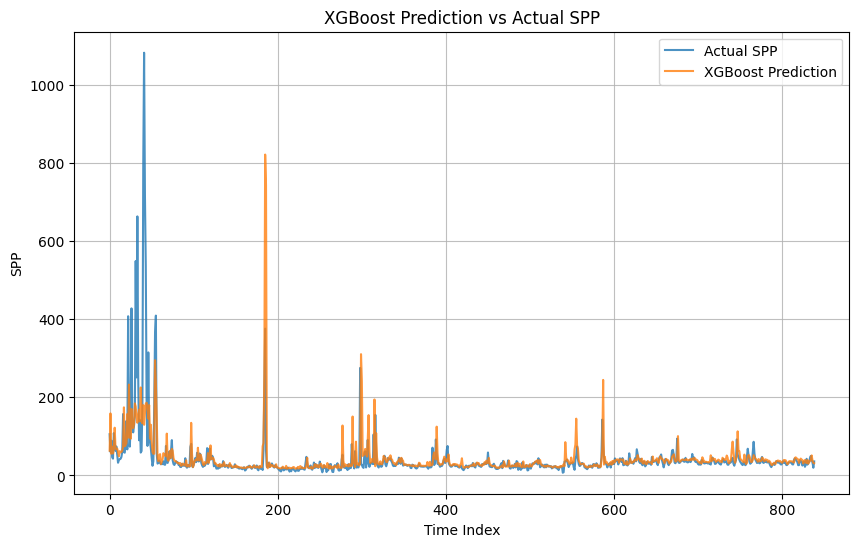

In [19]:
mask_xgb = xgb_preds != 0

y_true_xgb = y_all[mask_xgb]
y_pred_xgb = xgb_preds[mask_xgb]

plt.figure(figsize=(10,6))
plt.plot(y_true_xgb, label='Actual SPP', alpha=0.8)
plt.plot(y_pred_xgb, label='XGBoost Prediction', alpha=0.8)
plt.title("XGBoost Prediction vs Actual SPP")
plt.xlabel("Time Index")
plt.ylabel("SPP")
plt.legend()
plt.grid(True, alpha=0.8)
plt.show()

In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models

def make_sequences(X, y, seq_len=30):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i])
    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    return X_seq, y_seq

seq_len = 30
X_seq_all, y_seq_all = make_sequences(X_full_scaled, y_all, seq_len=seq_len)
M = len(X_seq_all)

def rolling_windows_seq(M, init_train=0.6, val_size=0.1, step=10):
    init_train_size = int(M * init_train)
    val_len = int(M * val_size)
    start = init_train_size
    while start + val_len <= M:
        train_idx = np.arange(0, start)
        val_idx = np.arange(start, start + val_len)
        yield train_idx, val_idx
        start += step

In [21]:
lstm_preds = np.zeros(M)

def build_lstm(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='mse'
    )
    return model

for train_idx, val_idx in rolling_windows_seq(M):
    X_tr, y_tr = X_seq_all[train_idx], y_seq_all[train_idx]
    X_val, y_val = X_seq_all[val_idx], y_seq_all[val_idx]

    lstm = build_lstm(X_seq_all.shape[1:])
    lstm.fit(
        X_tr, y_tr,
        epochs=20,
        batch_size=64,
        verbose=0,
    )

    lstm_preds[val_idx] = lstm.predict(X_val, verbose=0).ravel()

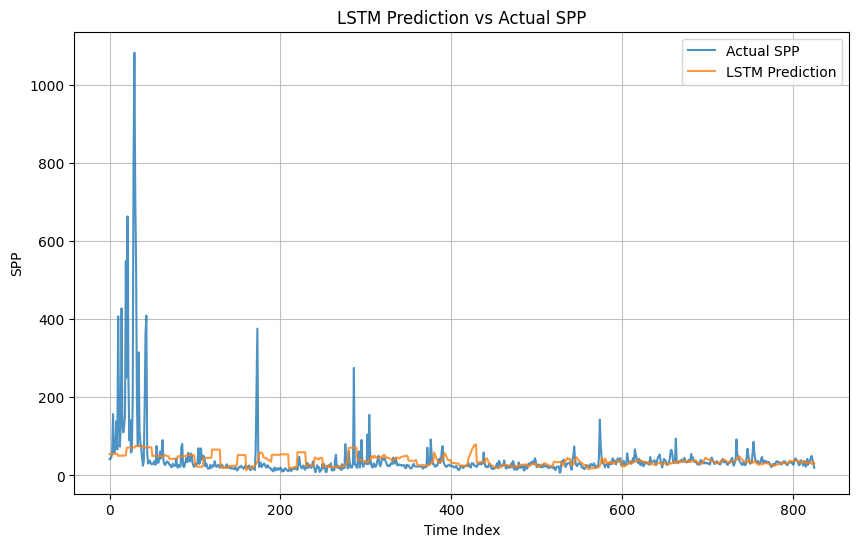

In [22]:
import matplotlib.pyplot as plt

mask = lstm_preds != 0

y_true = y_seq_all[mask]
y_pred = lstm_preds[mask]

plt.figure(figsize=(10,6))
plt.plot(y_true, label='Actual SPP', alpha=0.8)
plt.plot(y_pred, label='LSTM Prediction', alpha=0.8)
plt.title("LSTM Prediction vs Actual SPP")
plt.xlabel("Time Index")
plt.ylabel("SPP")
plt.legend()
plt.grid(True, alpha=0.8)
plt.show()

In [25]:
mask_xgb = xgb_preds != 0
xgb_rmse = np.sqrt(mean_squared_error(y_all[mask_xgb], xgb_preds[mask_xgb]))

mask_lstm = lstm_preds != 0
lstm_rmse = np.sqrt(mean_squared_error(y_seq_all[mask_lstm], lstm_preds[mask_lstm]))

print("XGBoost RMSE:", xgb_rmse)
print("LSTM RMSE:", lstm_rmse)

XGBoost RMSE: 65.69661722470732
LSTM RMSE: 69.21954573444481


In [38]:
xgb_preds_seq = xgb_preds[-M:]
mask_xgb_seq = xgb_preds_seq != 0

mask = mask_lstm & mask_xgb_seq

y_eval = y_seq_all[mask]
xgb_eval = xgb_preds_seq[mask]
lstm_eval = lstm_preds[mask]

for w_xgb in [1.0, 0.9, 0.8, 0.7, 0.6, 0.5]:
    w_lstm = 1.0 - w_xgb
    ens = w_xgb * xgb_eval + w_lstm * lstm_eval
    rmse = np.sqrt(mean_squared_error(y_eval, ens))
    print(f"w_xgb = {w_xgb:.1f}, w_lstm = {w_lstm:.1f}, Ensemble RMSE = {rmse:.2f}")

w_xgb, w_lstm = 0.6, 0.6
ensemble_preds = w_xgb * xgb_eval + w_lstm * lstm_eval

xgb_rmse = np.sqrt(mean_squared_error(y_eval, xgb_eval))
lstm_rmse = np.sqrt(mean_squared_error(y_eval, lstm_eval))
ensemble_rmse = np.sqrt(mean_squared_error(y_eval, ensemble_preds))

print("Aligned XGBoost RMSE:", xgb_rmse)
print("Aligned LSTM RMSE:", lstm_rmse)

w_xgb = 1.0, w_lstm = 0.0, Ensemble RMSE = 66.05
w_xgb = 0.9, w_lstm = 0.1, Ensemble RMSE = 64.74
w_xgb = 0.8, w_lstm = 0.2, Ensemble RMSE = 63.78
w_xgb = 0.7, w_lstm = 0.3, Ensemble RMSE = 63.19
w_xgb = 0.6, w_lstm = 0.4, Ensemble RMSE = 62.96
w_xgb = 0.5, w_lstm = 0.5, Ensemble RMSE = 63.12
Aligned XGBoost RMSE: 66.04676506641464
Aligned LSTM RMSE: 69.21954573444481


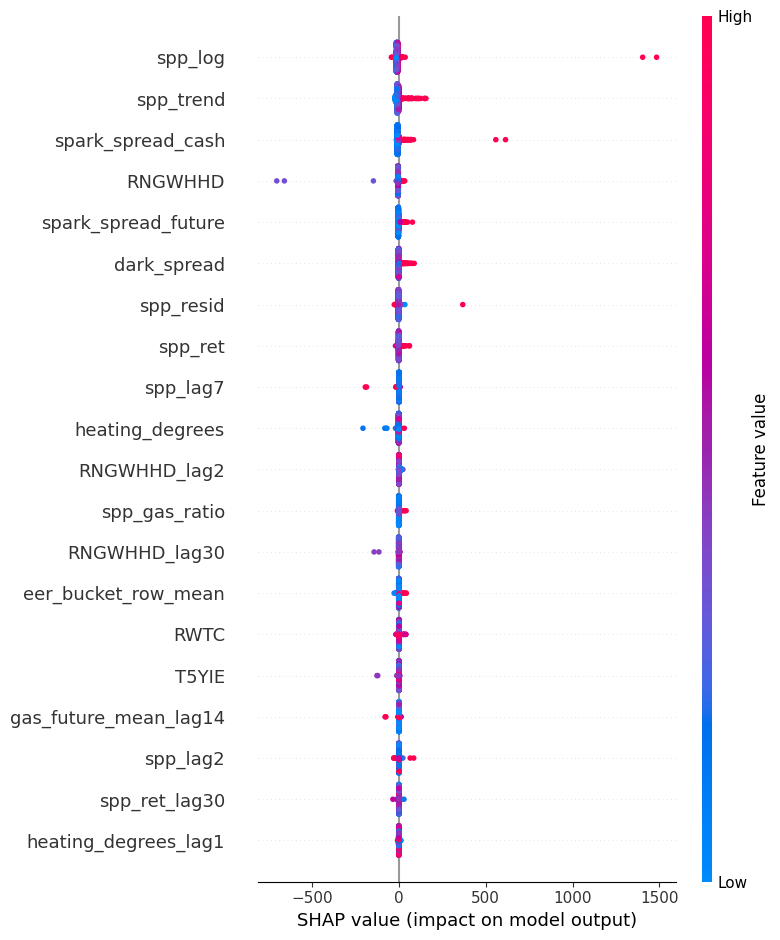

In [39]:
import shap

best_xgb = xgb_models[-1]

# choose a recent window of data for SHAP analysis
X_shap = X_all[-1000:, 1:]

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_shap)

# feature names matter for plots
shap.summary_plot(shap_values, X_shap, feature_names=feature_cols[1:])



*   **XGBoost** fits most of the distribution very well, but underpredicts the most extreme price spikes. Potential reason is SPP extreme spikes can come from structural shocks not fully captured by features.
*   The **LSTM** learns trend and temporal patterns, but smooths out rare events.

Both return similar RMSE value, because XGBoost learns short-term nonlinear relationships while LSTM learns sequential patterns.

From the SHAP values, we can see:

*   `spp_log` appears to be the strongest predictor.
*   `spark_spread_cas` indicates gas cost is relative to power price.
*   `RNGWHHD: gas price affects SPP but not as strongly as spreads.



